In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json
from glob import glob
from progress.bar import Bar
import pandas as pd

In [3]:
results = []
files = glob("experiment_results/*")
with Bar("Loading Results", max = len(files)) as bar:
    for file in files:
        with open(file) as f:
            results.append(json.loads(f.read().replace("inf", "Infinity")))
            # try:
            #     results.append(json.load(f))
            # except:
            #     print(file)
            #     results.append(json.loads(f.read().replace("inf", "Infinity")))
        bar.next()

In [4]:
with open("experiment_results/den520d_135_180_211_45_sipp_1.out") as f:
    print(json.loads(f.read().replace("inf", "Infinity")))

{'filename': 'maps/den520/den520d.map', 'algorithm': 'sipp', 'seed': 1, 'scenario': {'start_x': 135, 'start_y': 180, 'goal_x': 211, 'goal_y': 45}, 'results': [{'arrival_time': inf, 'metadata': {'generated': 30266, 'decreased': 1237, 'expanded': 30267, 'learnexpanded': 0, 'searchruntime_ms': 37.1273, 'learnruntime_ms': 0}}]}


In [5]:
!cat experiment_results/den520d_135_180_211_45_sipp_1.out


{
"filename": "maps/den520/den520d.map",
"algorithm": "sipp",
"seed": 1,
"scenario": {
 "start_x": 135,
 "start_y": 180,
 "goal_x": 211,
 "goal_y": 45
 },
"results": [
{"arrival_time": inf,
"metadata": {
 "generated": 30266,
 "decreased": 1237,
 "expanded": 30267,
 "learnexpanded": 0,
 "searchruntime_ms": 37.1273,
 "learnruntime_ms": 0
 }
}
]
}


In [71]:
with open(file) as f:
    json.load(f)

JSONDecodeError: Expecting value: line 12 column 18 (char 185)

In [12]:
res = results[1]
res

{'filename': 'maps/den520/den520d.map',
 'algorithm': 'asipp',
 'seed': 0,
 'scenario': {'start_x': 140, 'start_y': 226, 'goal_x': 13, 'goal_y': 74},
 'results': [{'arrival_time': 0,
   'metadata': {'generated': 17072,
    'decreased': 625,
    'expanded': 17073,
    'learnexpanded': 0,
    'searchruntime_ms': 20.6855,
    'learnruntime_ms': 0}}],
 'solution_compound_atf': []}

In [6]:
columns = [
    "filename",
    "algorithm",
    "seed",
    "start_x", "start_y", "goal_x", "goal_y",
    "sum_generated",
    "sum_decreased",
    "sum_expanded",
    "n_tref",
    "runtime"]

def process_results(results):
    n_tref = 0
    sum_gen = 0
    sum_dec = 0
    sum_exp = 0
    runtime = 0.0
    for r in results:
        n_tref += 1
        sum_gen += r['metadata']['generated']
        sum_dec += r['metadata']['decreased']
        sum_exp += r['metadata']['expanded']
        runtime += r['metadata']['searchruntime_ms']
    return sum_gen, sum_dec, sum_exp, n_tref, runtime

In [7]:
def mkrow(res):
    return [res['filename'], res['algorithm'], res['seed'], res['scenario']['start_x'], res['scenario']['start_y'], res['scenario']['goal_x'], res['scenario']['goal_y'],
 *process_results(res['results']) ]

In [8]:
x = []
for res in results:
    x.append(mkrow(res))
data = pd.DataFrame(data = x, columns = columns)

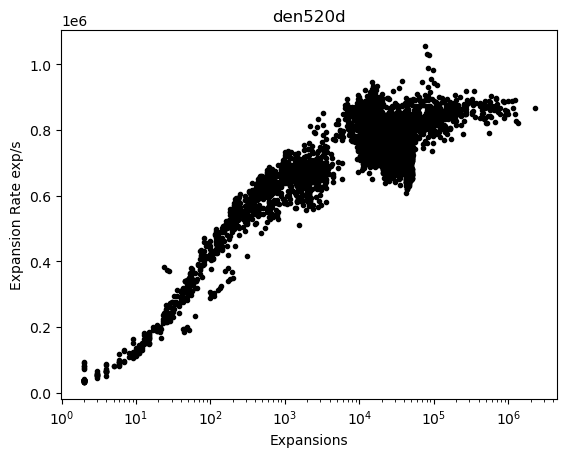

In [9]:
plt.plot(data.sum_expanded, data.sum_expanded/(data.runtime / 1000), ".k")
plt.xscale("log")
plt.xlabel("Expansions")
plt.ylabel("Expansion Rate exp/s")
plt.title("den520d")
plt.show()

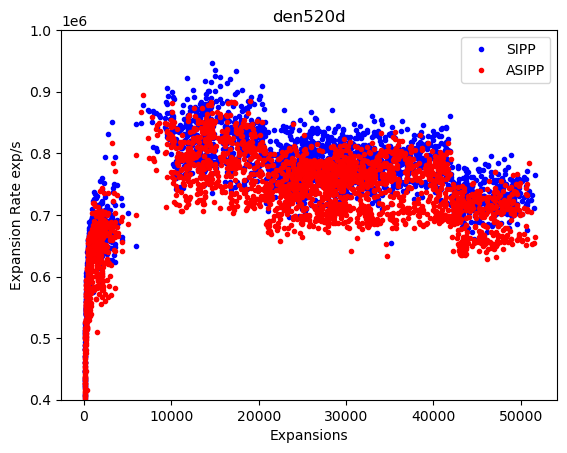

In [10]:
asipp_dat = data[data.algorithm == "asipp"]
sipp_dat = data[data.algorithm == "sipp"]

plt.plot(sipp_dat.sum_expanded, sipp_dat.sum_expanded/(sipp_dat.runtime / 1000), ".b", label = "SIPP")
plt.plot(asipp_dat.sum_expanded, asipp_dat.sum_expanded/(asipp_dat.runtime / 1000), ".r", label = "ASIPP")

#plt.xscale("log")
plt.xlabel("Expansions")
plt.ylabel("Expansion Rate exp/s")
plt.title("den520d")
plt.ylim([400000, 1000000])
plt.legend()
plt.savefig("overhead.png")

In [111]:
100*(asipp_dat.runtime.sum() - sipp_dat.runtime.sum())/sipp_dat.runtime.sum()

np.float64(4.569514544044008)

In [95]:
dat = data[data.algorithm == "asipp"]
dat

,filename,algorithm,seed,start_x,start_y,goal_x,goal_y,sum_generated,sum_decreased,sum_expanded,n_tref,runtime
1,maps/den520/den520d.map,asipp,0,140,226,13,74,17072,625,17073,1,20.685500
2,maps/den520/den520d.map,asipp,2,148,215,211,195,14535,444,14536,1,16.534200
3,maps/den520/den520d.map,asipp,1,100,41,122,35,478,20,219,1,0.426745
4,maps/den520/den520d.map,asipp,2,171,119,161,50,2807,179,1701,1,2.628950
6,maps/den520/den520d.map,asipp,2,94,173,14,189,48922,1672,48923,1,70.801700
...,...,...,...,...,...,...,...,...,...,...,...,...
7814,maps/den520/den520d.map,asipp,1,87,177,225,182,47563,1546,47564,1,64.926800
7815,maps/den520/den520d.map,asipp,1,217,71,143,95,43942,1504,43943,1,63.072300
7817,maps/den520/den520d.map,asipp,2,58,150,243,53,42398,1422,42399,1,57.592200
7819,maps/den520/den520d.map,asipp,0,127,168,152,45,38777,1456,38778,1,54.724700


In [12]:
dat = data[data.algorithm == "repeat"]
dat

,filename,algorithm,seed,start_x,start_y,goal_x,goal_y,sum_generated,sum_decreased,sum_expanded,n_tref,runtime
0,maps/den520/den520d.map,repeat,0,130,229,212,39,19271,669,19272,1,25.368700
12,maps/den520/den520d.map,repeat,1,165,17,168,91,18283,771,18284,1,25.581000
18,maps/den520/den520d.map,repeat,2,6,214,125,60,9499,431,9500,1,12.850000
19,maps/den520/den520d.map,repeat,0,186,178,185,141,69171,4607,38743,83,49.143003
20,maps/den520/den520d.map,repeat,0,104,173,129,229,44449,1523,44450,1,60.053800
...,...,...,...,...,...,...,...,...,...,...,...,...
7821,maps/den520/den520d.map,repeat,1,81,51,51,167,32385,1059,32386,1,43.830300
7823,maps/den520/den520d.map,repeat,0,169,148,167,21,42640,1356,42641,1,63.754500
7824,maps/den520/den520d.map,repeat,1,212,54,6,214,41957,1465,41958,1,62.880600
7827,maps/den520/den520d.map,repeat,1,130,59,192,78,16775,560,16776,1,21.157200


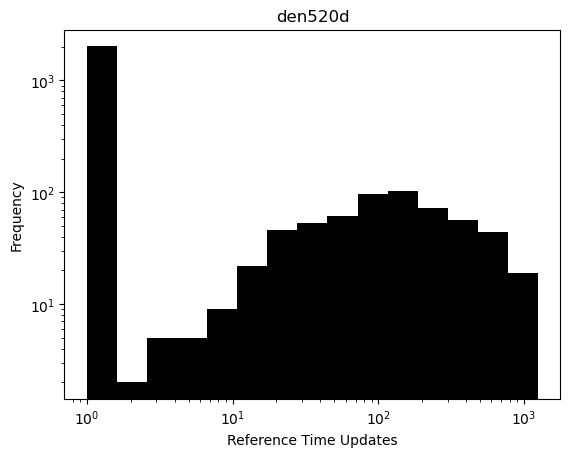

In [13]:
logbins = np.geomspace(dat.n_tref.min(), dat.n_tref.max(), 16) 
plt.hist(dat.n_tref, bins = logbins, facecolor="k")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("Frequency")
plt.xlabel("Reference Time Updates")
plt.title("den520d")
plt.savefig("plan-size.png")

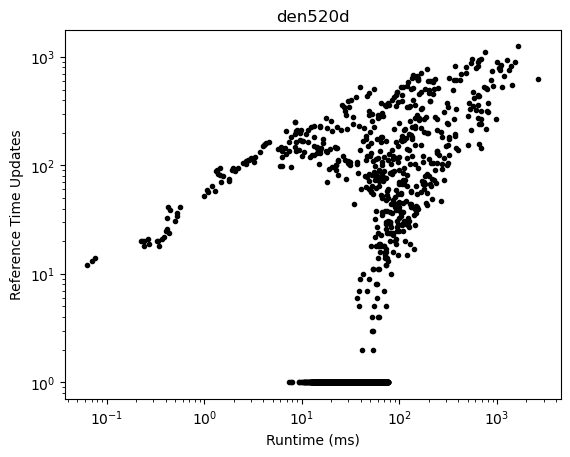

In [17]:
plt.plot(dat.runtime, dat.n_tref, ".k")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Runtime (ms)")
plt.ylabel("Reference Time Updates")
plt.title("den520d")
plt.savefig("rtplan.png")